# Projet de Machine Learning 

In [1]:
# Chargement des librairies nécessaires
library(ggplot2)    # Création de graphiques
library(tidyverse)  # Ensemble de packages pour manipuler, nettoyer et visualiser les données (inclut ggplot2, dplyr, tidyr...)
library(gridExtra)  # Permet d'afficher plusieurs graphiques sur une même page 
library(GGally)     # Extension de ggplot2 pour explorer les relations entre variables (ex : matrices de graphiques avec ggpairs)
library(plotly)     # Transformation de graphiques en versions interactives (zoom, survol, 3D)
library(corrplot)   # Visualisation des matrices de corrélation entre variables
library(reshape2)   # Transformation des données (format large ↔ format long)
library(FactoMineR) # Réalisation d’analyses multivariées (ACP, AFC, clustering...)
library(factoextra) # Visualisation des résultats des analyses faites avec FactoMineR
library(glmnet)     # Modèles de régression avec régularisation (Lasso, Ridge)
library(ggfortify)  # Visualisation simplifiée des modèles statistiques avec ggplot2
library(pROC)       # Calcul et tracé des courbes ROC + AUC pour évaluer un modèle
library(ROCR)       # Évaluation des performances de modèles de classification (ROC, précision, rappel...)
library(e1071)      # SVM
library(caret)      # SVM deuxieme option
library(MASS)       # Analyse discriminante
library(class)      # kNN

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : ‘gridExtra’


L'objet suivant est masqué depuis ‘package:dplyr’:

    combine



Attachement du package : ‘plotly’


L'objet suivant est masqué depuis ‘package:ggplot2’:

    last_plot


L'objet suivant est masqué depuis ‘package:stats’:

    filter


L'objet suivant est masqué depuis ‘package:graphics’:

    layout


corrplot 0.95 loaded


Attachement du package : ‘reshape2’


L'objet suivant est masqué depuis ‘package:tidyr’:

    smiths


Welcome! Want to learn more

In [2]:
# Pour installer les packages si besoin

#install.packages("ggplot2")
#install.packages("tidyverse")
#install.packages("gridExtra")
#install.packages("GGally")
#install.packages("plotly")
#install.packages("corrpolt")

#install.packages("FactoMineR")
#install.packages("factoextra")



#install.packages("MASS")
#install.packages("dplyr")

#install.packages("stats")
#install.packages("graphics")
#install.packages("pROC")

#packages <- c("ggplot2","tidyverse","gridExtra","GGally","plotly","corrplot","reshape2","FactoMineR","factoextra","glmnet","ggfortify","pROC","ROCR")

# 1. Introduction


## Présentation du jeu de données 


Dans ce projet, nous nous intéressons à un jeu de données synthétique comprenant 15 000 dossiers de patients, intégrant des variables démographiques, physiologiques et comportementales (âge, IMC, pression artérielle, cholestérol, habitudes de vie, etc.). Bien que ces données soient artificielles, elles ont été construites de manière à reproduire des corrélations réalistes observées en pratique médicale.

L’objectif principal est de prédire le risque de maladie cardiovasculaire (Heart_Disease_Risk) à partir de l’ensemble des variables explicatives, en mobilisant différentes méthodes de machine learning. Dans un second temps, nous chercherons également à prédire le taux de cholestérol LDL, indicateur clé du risque cardiovasculaire.

Pour répondre à ces objectifs, nous commencerons par une analyse exploratoire approfondie des données afin de mieux comprendre leur structure et les relations entre variables. Nous comparerons ensuite plusieurs modèles de prédiction, en évaluant leurs performances et leur capacité d’interprétation. Enfin, nous discuterons la cohérence des résultats obtenus au regard de l’analyse descriptive initiale.

Les données sont extraites et mises en forme, elles sont décrites par les variables suivantes :
* **Patient_ID** : identifiant unique pour chaque patient ;  
* **Age** : âge du patient (en années) ;  
* **Gender** : genre du patient ; qualitative à deux modalités ;  
* **Height_cm** : taille du patient en centimètres ;  
* **Weight_kg** : poids du patient en kilogrammes ;  
* **BMI** : indice de masse corporelle (IMC), calculé à partir de la taille et du poids (kg/m²) ;  
* **Systolic_BP** : pression artérielle systolique (mmHg) ;  
* **Diastolic_BP** : pression artérielle diastolique (mmHg) ;  
* **Cholesterol_Total** : cholestérol sérique total (mg/dL) ;  
* **Cholesterol_LDL** : lipoprotéines de basse densité (« mauvais » cholestérol) (mg/dL) ;  
* **Cholesterol_HDL** : lipoprotéines de haute densité (« bon » cholestérol) (mg/dL) ;  
* **Fasting_Blood_Sugar** : taux de glycémie à jeun (mg/dL) ;  
* **Smoking_Status** : statut tabagique ; qualitative à deux modalités ;  
* **Alcohol_Consumption** : niveau de consommation d’alcool ; qualitative à trois modalités ;  
* **Physical_Activity_Level** : niveau d’activité physique ; qualitative à quatre modalités ;  
* **Family_History** : antécédents familiaux de maladie cardiaque ; qualitative à deux modalités ;  
* **Stress_Level** : niveau de stress auto-déclaré ; échelle de 1 à 10 ;  
* **Sleep_Hours** : nombre moyen d’heures de sommeil par nuit ;  
* **Heart_Disease_Risk** : risque d’accident cardiaque ; qualitative à deux modalités : 0 (risque faible) ou 1 (risque élevé).  

In [2]:
# Lecture des données
# path="http://www.math.univ-toulouse.fr/~besse/Wikistat/data/"
path <- "./"
data <- read.table(paste(path, "healthcare_synthetic_data.csv", sep = ""),
                    sep = ",", header = TRUE)
# Affiche les premières lignes du jeu de données 
head(data)
# Vérification du contenu
summary(data)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


  Patient_ID             Age            Gender         Height_cm    
 Length:15000       Min.   :25.00   Min.   :0.0000   Min.   :138.5  
 Class :character   1st Qu.:46.00   1st Qu.:0.0000   1st Qu.:158.5  
 Mode  :character   Median :55.00   Median :0.0000   Median :164.7  
                    Mean   :54.54   Mean   :0.4919   Mean   :165.3  
                    3rd Qu.:63.00   3rd Qu.:1.0000   3rd Qu.:172.0  
                    Max.   :85.00   Max.   :1.0000   Max.   :198.1  
   Weight_kg           BMI         Systolic_BP     Diastolic_BP   
 Min.   : 33.70   Min.   :14.50   Min.   : 90.0   Min.   : 60.00  
 1st Qu.: 65.20   1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00  
 Median : 73.90   Median :27.20   Median :135.0   Median : 91.00  
 Mean   : 75.25   Mean   :27.45   Mean   :135.1   Mean   : 90.54  
 3rd Qu.: 83.90   3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :150.10   Max.   :46.10   Max.   :182.0   Max.   :120.00  
 Cholesterol_Total Cholesterol_LDL Cholesterol_H

In [3]:
# est ce que on compte stress level en quali ou quanti ? Stress_Level : niveau de stress auto-déclaré : échelle de 1 à 10 ; 
# données "propres", sans trous, bien codées et de petites tailles ?

In [4]:
# Conversion des variables qualitatives en facteur 

data[, "Gender"] <- as.factor(data[, "Gender"])
data[, "Smoking_Status"] <- as.factor(data[, "Smoking_Status"])
data[, "Alcohol_Consumption"] <- as.factor(data[, "Alcohol_Consumption"])
data[, "Physical_Activity_Level"] <- as.factor(data[, "Physical_Activity_Level"])
data[, "Family_History"] <- as.factor(data[, "Family_History"])
data[, "Heart_Disease_Risk"] <- as.factor(data[, "Heart_Disease_Risk"])

In [6]:
# on retire la colonne Patient_ID des données car elle n'est pas utile à l'étude
data$Patient_ID <- NULL

# 3. Modélisation

###  Division du jeu de données en un échantillon d’apprentissage et un échantillon test

Pour évaluer correctement un modèle, on divise le jeu de données en échantillon d’apprentissage (80%) et échantillon test (20%). L’échantillon d’apprentissage sert à entraîner le modèle, tandis que l’échantillon test permet de mesurer ses performances sur des données jamais vues. Cette étape est nécessaire pour éviter le surapprentissage et obtenir une estimation réaliste de la capacité du modèle à généraliser à de nouvelles données.

In [7]:
set.seed(111) # initialisation du générateur
# SPLIT
test.ratio <- .2 #20% de l'échantillon pour les tests et le reste pour l'apprentissage
npop <- nrow(data) # nombre de lignes dans les données
nvar <- ncol(data) # nombre de colonnes
ntest <- ceiling(npop * test.ratio) # taille de l'échantillon test
testi <- sample(1:npop, ntest) # indices de l'échantillon test
appri <- setdiff(1:npop, testi) # indices de l'échantillon d'apprentissage

Construction des échantillons pour la classification : prévision du risque d’accident cardiaque "Heart_Disease_Risk".

In [8]:
# SÉPARER X et y
# construction de l'échantillon d'apprentissage
datappr0 <- data[appri, -which(names(data) == "Heart_Disease_Risk")] # on retire la colonne "Heart_Disease_Risk"
# construction de l'échantillon test
datestr0 <- data[testi, -which(names(data) == "Heart_Disease_Risk")] 
# on récupère la variable cible 
y_train <- data$Heart_Disease_Risk[appri]
y_test  <- data$Heart_Disease_Risk[testi] 

# vérification
# str(datappr0)
# str(datestr0)

# NORMALISATION (stats du train uniquement)
num_cols <- sapply(datappr0, is.numeric) # on identifie les colonnes numériques
# on normalise l'échantillon d'apprentissage (seulement les variables numeric et integer)
datappr <- datappr0
datappr[, num_cols] <- scale(datappr0[, num_cols])
# on normalise l'échantillon test 
# à l'aide des caractéristiques de l'échantillon d'apprentissage
datestr <- datestr0
datestr[, num_cols] <- scale(
  datestr0[, num_cols],
  center = sapply(datappr0[, num_cols], mean), # on centre avec les moyennes de l'échantillon d'apprentissage
  scale  = sapply(datappr0[, num_cols], sd)    # on réduit avec les écart-types de l'échantillon d'apprentissage
)

# vérification
# summary(datappr)
# summary(datestr)


# Encoder les var quali
X_train <- as.data.frame(model.matrix(~ ., data = datappr)[, -1])
X_test  <- as.data.frame(model.matrix(~ ., data = datestr)[, -1])

## Prévision par SVM : SVC pour Heart_Disease_Risk

Dans cette partie, l’objectif est de prédire s’il existe un risque de maladie cardiaque (variable Heart_Disease_Risk). Il s’agit d’un problème de classification binaire.

**SVM : Noyau Gaussien**

[1] "Valeur de cost retenu : 1"


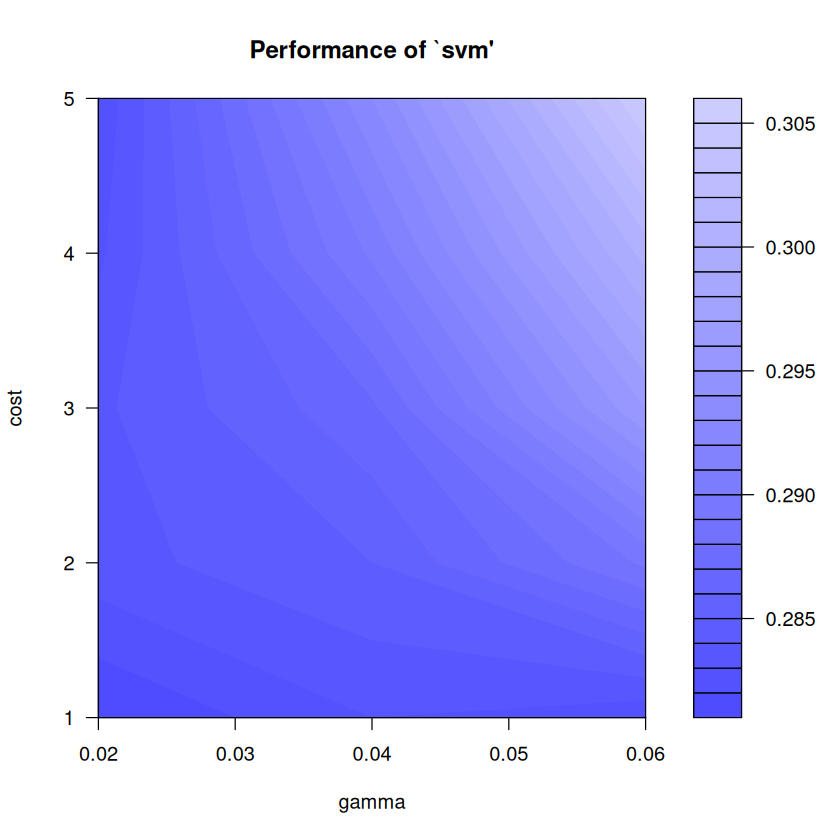

In [9]:
# Ajouter y_train pour svm()
X_train$Heart_Disease_Risk <- y_train
X_train_small <- X_train[sample(nrow(X_train), 5000), ] #15 000 dossiers en tout

# SVM avec noyau gaussien (RBF) : tune des hyperparamètres
QUICK <- FALSE

if (!QUICK){
    svm.tune <- tune.svm(
       Heart_Disease_Risk ~ .,
       data  = X_train_small, # si X_train_small, on test sur un sous-échantillon pour aller plus vite
       cost  = c(1, 2, 3, 4, 5),
       gamma = seq(0.02, 0.06, by = 0.02),
       tunecontrol = tune.control(cross = 10) # pour aller un peu plus vite on réduit la valeur
     )
    plot(svm.tune)
    print(paste("Valeur de cost retenu : ", svm.tune$best.parameters$cost, sep=""))
} else {
  svm.tune <- list(best.parameters = list(cost = 1))
}

In [11]:
# Modèle avec paramètres optimaux
svm.fit <- svm(
  Heart_Disease_Risk ~ .,
  data  = X_train,
  cost  = svm.tune$best.parameters$cost,
  gamma = svm.tune$best.parameters$gamma,
  probability = TRUE
)

# Prédiction sur le jeu de test
pred_svm <- predict(svm.fit, newdata = X_test, probability = TRUE)
print("Matrice de confusion : ")
table(Predicted = pred_svm, Actual = y_test) #matrice de confusion
print(paste("Accuracy du modèle :", mean(pred_svm == y_test))) # accuracy


[1] "Matrice de confusion : "


         Actual
Predicted    0    1
        0 1402  480
        1  318  800

[1] "Accuracy du modèle : 0.734"


#### Courbes ROC

In [12]:
# probabilités du modèle
proba <- attr(pred_svm, "probabilities")

Setting levels: control = 0, case = 1

Setting direction: controls > cases



Area under the curve: 0.787

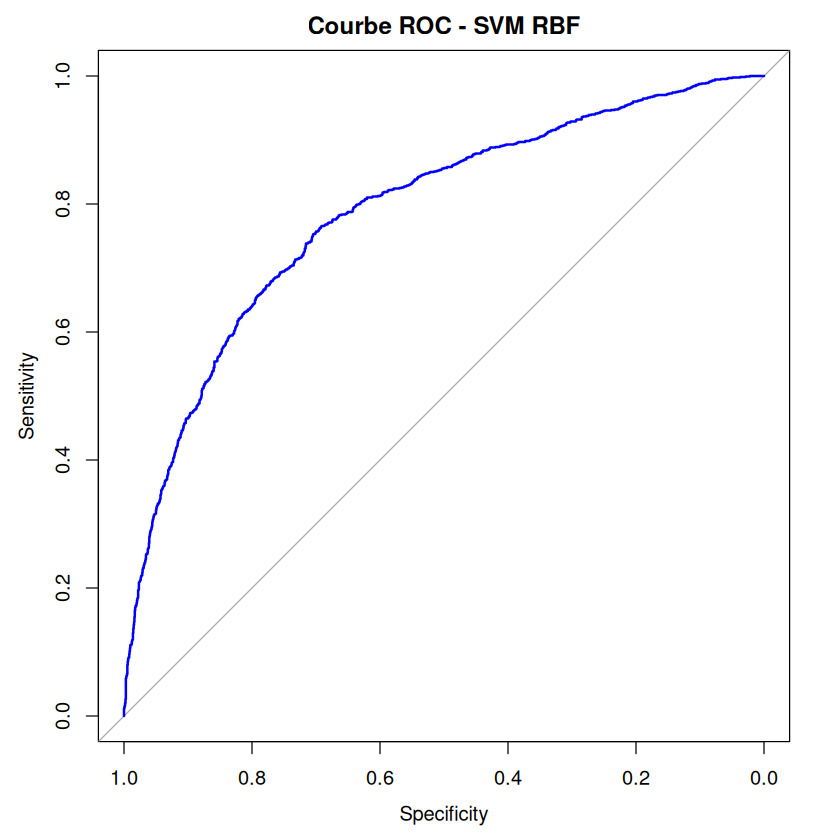

In [13]:
# attention il faut choisir la classe positive 
roc_svm <- roc(
  response = y_test,
  predictor = proba[, 1]  # colonne de la classe positive : quand le risque vaut 0
)

# plot ROC
plot(roc_svm, col = "blue", main = "Courbe ROC - SVM RBF")

# AUC
auc(roc_svm)

**SVM : Noyau Linéaire**

[1] "Valeur de cost retenu : 1"


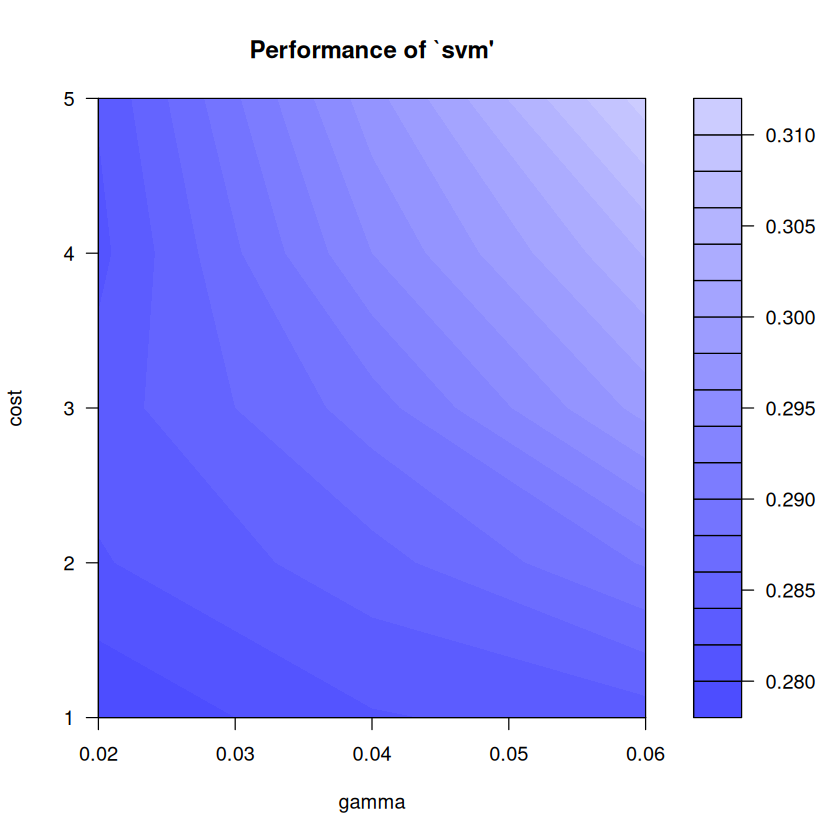

In [18]:
# noyau linéaire 
QUICK <- FALSE

if (!QUICK) {
    svm.lin.tune <- tune.svm(
        Heart_Disease_Risk ~ .,
        data  = X_train_small, # si X_train_small, on test sur un sous-échantillon pour aller plus vite
        cost  = c(1, 2, 3, 4, 5),
        gamma = seq(0.02, 0.06, by = 0.02),
        tunecontrol = tune.control(cross = 10) # pour aller un peu plus vite on réduit la valeur
    )
    plot(svm.lin.tune)
    print(paste("Valeur de cost retenu : ", svm.lin.tune$best.parameters$cost, sep=""))
} else {
  svm.lin.tune <- list(best.parameters = list(cost = 1, gamma = 0.02))
}


In [22]:
svm.lin <- svm(
  Heart_Disease_Risk ~ .,
  data = X_train_small,
  kernel = "linear",
  cost = svm.lin.tune$best.parameters$cost,
  probability = TRUE
)

# Prédiction sur le jeu de test
pred_svm.lin <- predict(svm.lin, newdata = X_test, probability = TRUE)
print("Matrice de confusion : ")
table(Predicted = pred_svm.lin, Actual = y_test) #matrice de confusion
print(paste("Accuracy du modèle :", mean(pred_svm.lin == y_test))) # accuracy

[1] "Matrice de confusion : "


         Actual
Predicted    0    1
        0 1319  478
        1  401  802

[1] "Accuracy du modèle : 0.707"


**SVM : Noyau polynomial**

[1] "Valeur de cost retenu : 1"
[1] "Valeur de gamma retenu : 0.02"
[1] "Valeur de degree retenu : 3"
[1] "Valeur de coef0 retenu : 0.5"


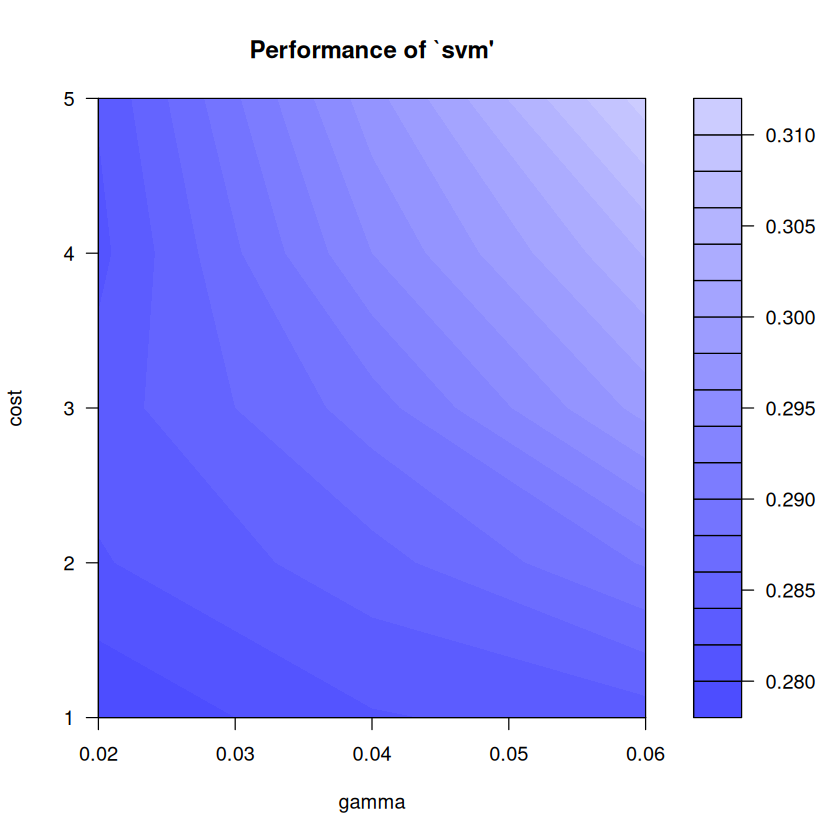

In [26]:
X_train_small <- X_train[sample(nrow(X_train), 5000), ] #15 000 dossiers en tout

QUICK <- FALSE

if (!QUICK) {
  # Ajustement du modèle avec validation croisée
  svm.pol.tune <- tune.svm(Heart_Disease_Risk ~ ., 
                           data = X_train_small,
                           coef0 = c(0, 0.5, 1, 2),
                           degree = c(2, 3),
                           cost  = c(1, 2, 3, 4, 5),
                           gamma = seq(0.02, 0.06, by = 0.02),
                           tunecontrol = tune.control(cross = 10), # pour aller un peu plus vite on réduit la valeur
                           kernel = "polynomial"
    )
  print(paste("Valeur de cost retenu : ", svm.pol.tune$best.parameters$cost, sep=""))
  print(paste("Valeur de gamma retenu : ", svm.pol.tune$best.parameters$gamma, sep=""))
  print(paste("Valeur de degree retenu : ", svm.pol.tune$best.parameters$degree, sep=""))
  print(paste("Valeur de coef0 retenu : ", svm.pol.tune$best.parameters$coef0, sep=""))
  plot(svm.lin.tune) 
} else {
  svm.pol.tune <- list(best.parameters = list(cost = 1, gamma = 0.02, coef0=1, degree=2)) 
}

In [27]:
svm.pol <- svm(
  Heart_Disease_Risk ~ .,
  data = X_train_small,
  kernel = "polynomial",
  cost = svm.pol.tune$best.parameters$cost,
  probability = TRUE
)

# Prédiction sur le jeu de test
pred_svm.pol <- predict(svm.pol, newdata = X_test, probability = TRUE)
print("Matrice de confusion : ")
table(Predicted = pred_svm.pol, Actual = y_test) #matrice de confusion
print(paste("Accuracy du modèle :", mean(pred_svm.pol == y_test))) # accuracy

[1] "Matrice de confusion : "


         Actual
Predicted    0    1
        0 1365  424
        1  355  856

[1] "Accuracy du modèle : 0.740333333333333"


**SVM : Noyau radial**

[1] "Valeur de cost retenu : 1"
[1] "Valeur de gamma retenu : 0.02"


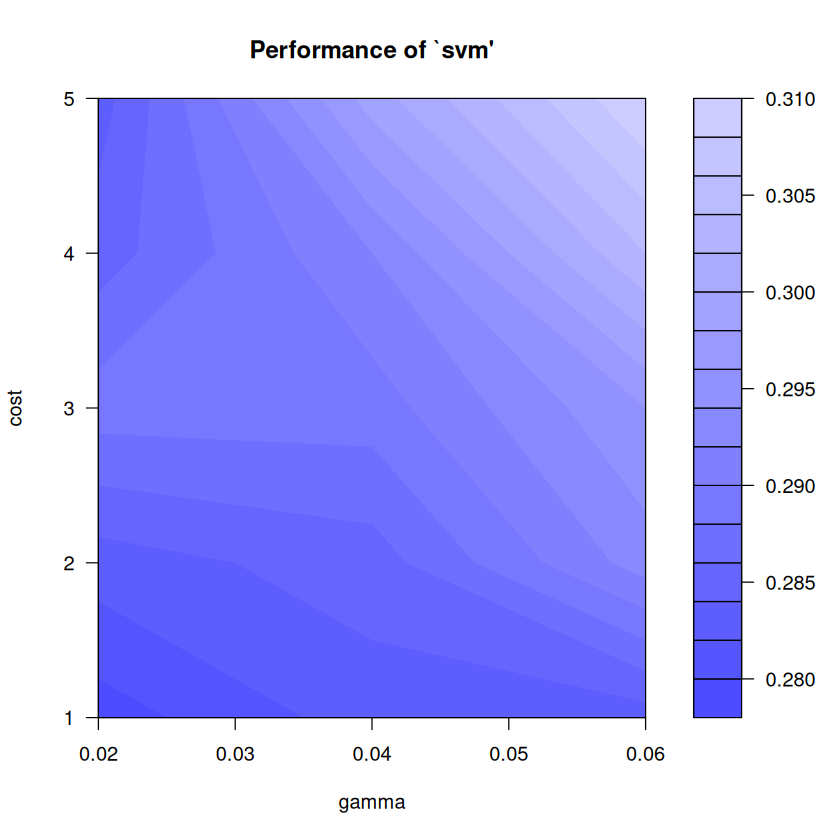

In [28]:
X_train_small <- X_train[sample(nrow(X_train), 1000), ] #15 000 dossiers en tout

QUICK <- FALSE

if (!QUICK) {
    svm.rad.tune <- tune.svm(
      Heart_Disease_Risk ~ .,
      data  = X_train_small, # si X_train_small, on test sur un sous-échantillon pour aller plus vite
      cost  = c(1, 2, 3, 4, 5),
      gamma = seq(0.02, 0.06, by = 0.02),
      tunecontrol = tune.control(cross = 10), # pour aller un peu plus vite on réduit la valeur
      kernel = "radial"
    )
    plot(svm.rad.tune)
    print(paste("Valeur de cost retenu : ", svm.rad.tune$best.parameters$cost, sep=""))
    print(paste("Valeur de gamma retenu : ", svm.rad.tune$best.parameters$gamma, sep=""))

} else {
  svm.rad.tune <- list(best.parameters = list(cost = 1, gamma = 0.02))
}

In [29]:
svm.rad <- svm(
  Heart_Disease_Risk ~ .,
  data = X_train_small,
  kernel = "radial",
  cost = svm.rad.tune$best.parameters$cost,
  probability = TRUE
)

# Prédiction sur le jeu de test
pred_svm.rad <- predict(svm.rad, newdata = X_test, probability = TRUE)
print("Matrice de confusion : ")
table(Predicted = pred_svm.rad, Actual = y_test) #matrice de confusion
print(paste("Accuracy du modèle :", mean(pred_svm.rad == y_test))) # accuracy

[1] "Matrice de confusion : "


         Actual
Predicted    0    1
        0 1319  478
        1  401  802

[1] "Accuracy du modèle : 0.707"


**Courbes ROC**

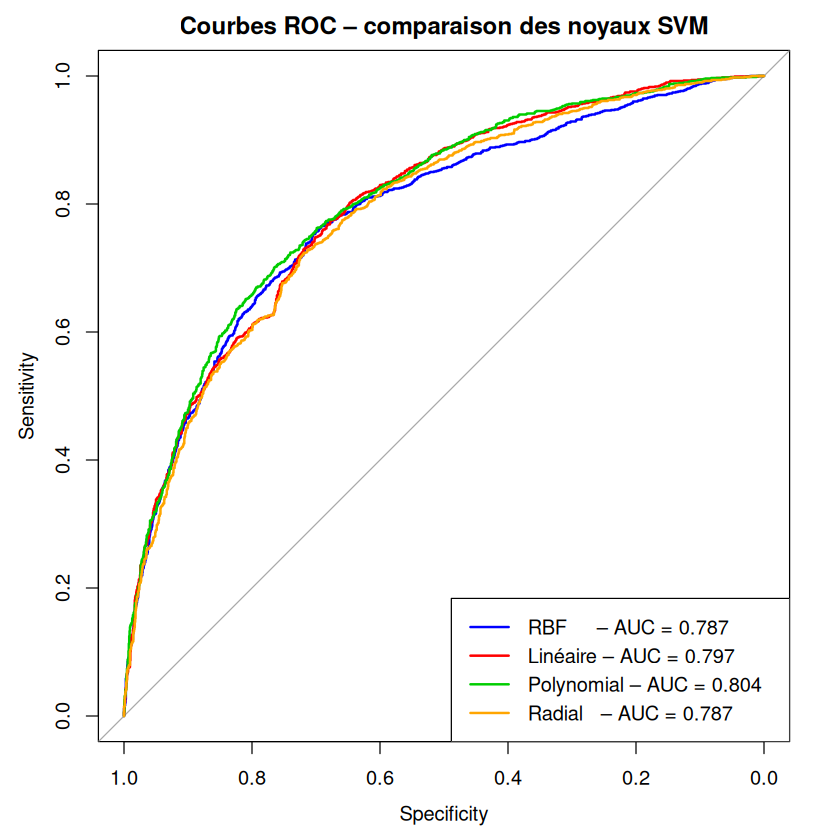

In [36]:
# Probabilités de chaque modèle
proba_rbf  <- attr(pred_svm,     "probabilities")[, "1"]
proba_lin  <- attr(pred_svm.lin, "probabilities")[, "1"]
proba_pol  <- attr(pred_svm.pol, "probabilities")[, "1"]
proba_rad  <- attr(pred_svm.rad, "probabilities")[, "1"]

# ROC
roc_rbf <- roc(response = y_test, predictor = proba_rbf, levels = c("0","1"), direction = "<")
roc_lin <- roc(response = y_test, predictor = proba_lin, levels = c("0","1"), direction = "<")
roc_pol <- roc(response = y_test, predictor = proba_pol, levels = c("0","1"), direction = "<")
roc_rad <- roc(response = y_test, predictor = proba_rad, levels = c("0","1"), direction = "<")

# Plot
plot(roc_rbf, col = "blue",   lwd = 2, main = "Courbes ROC – comparaison des noyaux SVM")
plot(roc_lin, col = "red",    lwd = 2, add = TRUE)
plot(roc_pol, col = "green3", lwd = 2, add = TRUE)
plot(roc_rad, col = "orange", lwd = 2, add = TRUE)

legend("bottomright",
  legend = c(
    paste0("RBF     – AUC = ", round(auc(roc_rbf), 3)),
    paste0("Linéaire – AUC = ", round(auc(roc_lin), 3)),
    paste0("Polynomial – AUC = ", round(auc(roc_pol), 3)),
    paste0("Radial   – AUC = ", round(auc(roc_rad), 3))
  ),
  col = c("blue","red","green3","orange"),
  lwd = 2
)

Nous allons aussi évaluer et comparer plusieurs autres modèles d’apprentissage automatique : LDA (Analyse Discriminante Linéaire), QDA (Analyse Discriminante Quadratique), kNN (k plus proches voisins), afin d’analyser leurs performances respectives sur ce problème de prédiction.

**1. Analyse discriminante linéaire**

La LDA n'offre pas de possibilité d'ajustement avec des hyperparamètres. Nous pouvons tout de même avoir accès à sa précision, et le *Cohen’s Kappa* (qui compare la précision du modèle à ce qu’on obtiendrait par un classement aléatoire).

In [31]:
# analyse discriminante linéaire
lda_model <- lda(Heart_Disease_Risk ~ ., data = X_train_small)

pred_lda <- predict(lda_model, X_test)$class

# matrice de confusion correcte
table(Predicted = pred_lda, Actual = y_test)

# accuracy
mean(pred_lda == y_test)

         Actual
Predicted    0    1
        0 1334  411
        1  386  869

[1] 0.7343333

**2. Analyse discriminante quadratique**

In [32]:
# analyse discriminante quadratique 
qda_model <- qda(Heart_Disease_Risk ~ ., data = X_train_small)

pred_qda <- predict(qda_model, X_test)$class

# matrice de confusion correcte
table(Predicted = pred_qda, Actual = y_test)

# accuracy
mean(pred_qda == y_test)

         Actual
Predicted    0    1
        0 1218  382
        1  502  898

[1] 0.7053333

**3. k plus proches voisins**

In [ ]:
# k plus proches voisins
train_x <- X_train_small[, -which(names(datappr_q) == "Heart_Disease_Risk")]
test_x  <- X_train_small[, -which(names(datestr_q) == "Heart_Disease_Risk")]

train_y <- X_train_small$Heart_Disease_Risk

pred_knn <- knn(
  train = train_x,
  test  = test_x,
  cl    = train_y,
  k = 10
)

table(pred_knn, datestr_q$Heart_Disease_Risk)
mean(pred_knn == datestr_q$Heart_Disease_Risk)

In [34]:
train_x <- X_train_small[, -which(names(X_train_small) == "Heart_Disease_Risk")] # train features
test_x <- X_test # test features
train_y <- X_train_small$Heart_Disease_Risk # train target

# prédiction KNN
pred_knn <- knn(
  train = train_x,
  test  = test_x,
  cl    = train_y,
  k = 10
)

# matrice de confusion
table(Predicted = pred_knn, Actual = y_test)

# accuracy
mean(pred_knn == y_test)

         Actual
Predicted    0    1
        0 1149  621
        1  571  659

[1] 0.6026667

In [38]:
# Prédictions de classe (les predict() sans probability retournent directement les classes)
acc_rbf <- mean(pred_svm     == y_test)
acc_lin <- mean(pred_svm.lin == y_test)
acc_pol <- mean(pred_svm.pol == y_test)
acc_rad <- mean(pred_svm.rad == y_test)
acc_lda <- mean(pred_lda     == y_test)
acc_qda <- mean(pred_qda     == y_test)
acc_knn <- mean(pred_knn     == y_test)

# Tableau récapitulatif
resultats <- data.frame(
  Modèle   = c("SVM – RBF (gaussien)", "SVM – Linéaire", 
                "SVM – Polynomial", "SVM – Radial",
                "LDA", "QDA", "kNN (k=10)"),
  Accuracy  = round(c(acc_rbf, acc_lin, acc_pol, acc_rad,
                       acc_lda, acc_qda, acc_knn), 4),
  AUC       = round(c(auc(roc_rbf), auc(roc_lin), auc(roc_pol), auc(roc_rad),
                       NA, NA, NA), 4)  # AUC non calculée pour LDA/QDA/kNN ici
)

# Tri du meilleur au moins bon
resultats <- resultats[order(-resultats$Accuracy), ]

print(resultats)

                Modèle Accuracy    AUC
3     SVM – Polynomial   0.7403 0.8041
5                  LDA   0.7343     NA
1 SVM – RBF (gaussien)   0.7340 0.7870
2       SVM – Linéaire   0.7070 0.7967
4         SVM – Radial   0.7070 0.7871
6                  QDA   0.7053     NA
7           kNN (k=10)   0.6027     NA


<div style="border-left:5px solid orange; padding:10px; background-color:#fff3cd;">
<b>Interprétation :</b>  Le modèle optimal est le modèle SVM à noyau polynomial.
</div>

le modèle optimal est le modèle SVM à noyau polynomial (meilleur accurancy et meilleur auc).
Pour le choix du noyau SVM : les AUC sont proches, on va donc favoriser le noyau linéaire (car plus simple, plus rapide et moins risque de surapprentissage). Si le noyau RBF ou radial donnait une AUC nettement supérieure, cela indiquerait que la frontière de décision est non linéaire dans l'espace des données.

Pour la comparaison globale : LDA et QDA supposent la normalité des variables avec des variables qualitatives encodées en indicatrices, ces hypothèses ne sont pas vraiment respectées, donc leurs performances peuvent être pénalisées. kNN est très sensible à la dimension. 
Les SVM sont en général plus robustes sur des données mixtes bien normalisées.

L’AUC (Area Under the Curve) mesure la capacité d’un modèle à distinguer correctement les deux classes à partir de la courbe ROC. Plus elle est proche de 1, meilleur est le modèle, tandis qu’une valeur de 0,5 correspond à un modèle aléatoire. Contrairement à l’accuracy, elle ne dépend pas d’un seuil de décision, ce qui la rend plus fiable pour comparer des modèles.

Dans un contexte médical comme la prédiction du risque de maladie cardiaque, les faux négatifs sont particulièrement graves, car ils correspondent à des patients malades non détectés par le modèle. C’est pourquoi on privilégie souvent des modèles avec une AUC élevée et une bonne sensibilité, afin de réduire au maximum ce type d’erreur critique.

# Prédiction du taux de mauvais cholestérol : Cholesterol_LDL (régression)

## Séparation des données en jeu de test et jeu d'entrainement

In [15]:
set.seed(111) # initialisation du générateur

# SPLIT (déjà fait mais je le laisse par simplicité)
test.ratio <- .2 # 20% de l'échantillon pour les tests et le reste pour l'apprentissage
npop <- nrow(data) # nombre de lignes dans les données
nvar <- ncol(data) # nombre de colonnes
ntest <- ceiling(npop * test.ratio) # taille de l'échantillon test
testi <- sample(1:npop, ntest) # indices de l'échantillon test
appri <- setdiff(1:npop, testi) # indices de l'échantillon d'apprentissage

# On sépare x et y
datappr0_svr <- data[appri, -which(names(data) == "Cholesterol_LDL")]
datestr0_svr  <- data[testi,  -which(names(data) == "Cholesterol_LDL")]
y_train_svr   <- data$Cholesterol_LDL[appri]
y_test_svr    <- data$Cholesterol_LDL[testi]

# Normalisation (train uniquement)
num_cols_svr <- sapply(datappr0_svr, is.numeric)
datappr_svr  <- datappr0_svr
datappr_svr[, num_cols_svr] <- scale(datappr0_svr[, num_cols_svr])
datestr_svr  <- datestr0_svr
datestr_svr[, num_cols_svr] <- scale(
  datestr0_svr[, num_cols_svr],
  center = sapply(datappr0_svr[, num_cols_svr], mean),  # ← stats du TRAIN
  scale  = sapply(datappr0_svr[, num_cols_svr], sd)
)

# Encodage des quali
X_train_svr <- as.data.frame(model.matrix(~ ., data = datappr_svr)[, -1])
X_test_svr  <- as.data.frame(model.matrix(~ ., data = datestr_svr)[, -1])
X_train_svr$Cholesterol_LDL <- y_train_svr

## Régression par SVM : SVR pour Cholesterol_LDL

On réalise une SVM sur les données pour la regression, on commence par rechercher les paramètres optimaux:

**SVR : Noyau gaussien**

In [ ]:
#X_train_svr <- X_train_svr[sample(nrow(X_train), 5000), ] #15 000 dossiers en tout

svr.rbf.tune <- tune.svm(
  Cholesterol_LDL ~ .,
  data  = X_train_svr,
  cost  = c(1, 2, 3, 4, 5),
  gamma = seq(0.02, 0.06, by = 0.02),
  tunecontrol = tune.control(cross = 10)
)
plot(svr.rbf.tune)
cat("Meilleur cost :", svr.rbf.tune$best.parameters$cost, "\n")
cat("Meilleur gamma :", svr.rbf.tune$best.parameters$gamma, "\n")

In [ ]:
# Modèle final
svr.rbf <- svm(
  Cholesterol_LDL ~ .,
  data  = X_train_svr,
  kernel = "radial",
  cost  = svr.rbf.tune$best.parameters$cost,
  gamma = svr.rbf.tune$best.parameters$gamma
)

# Résidus sur le train
fit.rbf <- svr.rbf$fitted
res.rbf <- fit.rbf - y_train_svr
gplot.res(fit.rbf, res.rbf, titre = "SVR RBF – résidus train")

# RMSE test
pred.rbf  <- predict(svr.rbf, newdata = X_test_svr)
rmse.rbf  <- sqrt(mean((y_test_svr - pred.rbf)^2))
print("RMSE SVR RBF :", rmse.rbf, "\n")

**SVR : Noyau linéaire**

In [ ]:
svr.lin.tune <- tune.svm(
  Cholesterol_LDL ~ .,
  data   = X_train_svr,
  kernel = "linear",
  cost   = c(0.5, 1, 2, 3, 5),
  tunecontrol = tune.control(cross = 10)
)
print("Meilleur cost :", svr.lin.tune$best.parameters$cost, "\n")

In [ ]:
svr.lin <- svm(
  Cholesterol_LDL ~ .,
  data   = X_train_svr,
  kernel = "linear",
  cost   = svr.lin.tune$best.parameters$cost
)

fit.lin <- svr.lin$fitted
res.lin <- fit.lin - y_train_svr
gplot.res(fit.lin, res.lin, titre = "SVR Linéaire – résidus train")

pred.lin <- predict(svr.lin, newdata = X_test_svr)
rmse.lin <- sqrt(mean((y_test_svr - pred.lin)^2))
print("RMSE SVR Linéaire :", rmse.lin, "\n")

**SVR : Noyau polynomial**

In [ ]:
svr.pol.tune <- tune.svm(
  Cholesterol_LDL ~ .,
  data   = X_train_svr,
  kernel = "polynomial",
  cost   = c(1, 2, 3, 5),
  gamma  = seq(0.02, 0.06, by = 0.02),
  degree = c(2, 3),
  coef0  = c(0, 0.5, 1),
  tunecontrol = tune.control(cross = 10)
)
print("Meilleur cost :", svr.pol.tune$best.parameters$cost, "\n")
print("Meilleur degree :", svr.pol.tune$best.parameters$degree, "\n")
print("Meilleur coef0 :", svr.pol.tune$best.parameters$coef0, "\n")

In [ ]:
svr.pol <- svm(
  Cholesterol_LDL ~ .,
  data   = X_train_svr,
  kernel = "polynomial",
  cost   = svr.pol.tune$best.parameters$cost,
  gamma  = svr.pol.tune$best.parameters$gamma,
  degree = svr.pol.tune$best.parameters$degree,
  coef0  = svr.pol.tune$best.parameters$coef0
)

fit.pol <- svr.pol$fitted
res.pol <- fit.pol - y_train_svr
gplot.res(fit.pol, res.pol, titre = "SVR Polynomial – résidus train")

pred.pol <- predict(svr.pol, newdata = X_test_svr)
rmse.pol <- sqrt(mean((y_test_svr - pred.pol)^2))
print("RMSE SVR Polynomial :", rmse.pol, "\n")

**SVR : Noyau radial**

In [ ]:
svr.rad.tune <- tune.svm(
  Cholesterol_LDL ~ .,
  data   = X_train_svr,
  kernel = "radial",
  cost   = c(1, 2, 3, 5),
  gamma  = seq(0.02, 0.06, by = 0.02),
  degree = c(2, 3),
  coef0  = c(0, 0.5, 1),
  tunecontrol = tune.control(cross = 10)
)
print("Meilleur cost :", svr.rad.tune$best.parameters$cost, "\n")

In [ ]:
svr.rad <- svm(
  Cholesterol_LDL ~ .,
  data   = X_train_svr,
  kernel = "radial",
  cost   = svr.rad.tune$best.parameters$cost,
  gamma  = svr.rad.tune$best.parameters$gamma,
  degree = svr.rad.tune$best.parameters$degree,
  coef0  = svr.rad.tune$best.parameters$coef0
)

fit.rad <- svr.rad$fitted
res.rad <- fit.rad - y_train_svr
gplot.res(fit.rad, res.rad, titre = "SVR Radial – résidus train")

pred.pol <- predict(svr.rad, newdata = X_test_svr)
rmse.pol <- sqrt(mean((y_test_svr - pred.rad)^2))
print("RMSE SVR Radial :", rmse.rad, "\n")

In [ ]:
# ── Tableau récapitulatif ──────────────────────────────────────────────────────
resultats_svr <- data.frame(
  Noyau = c("RBF (gaussien)", "Linéaire", "Polynomial"),
  RMSE  = round(c(rmse.rbf, rmse.lin, rmse.pol), 4),
  R2    = round(c(
    cor(y_test_svr, pred.rbf)^2,
    cor(y_test_svr, pred.lin)^2,
    cor(y_test_svr, pred.pol)^2
  ), 4)
)
resultats_svr <- resultats_svr[order(resultats_svr$RMSE), ]
print(resultats_svr)

In [ ]:
# ── Graphe prédictions vs valeurs réelles (meilleur noyau) ────────────────────
# Remplace pred.rbf par le noyau qui a le meilleur RMSE selon ton tableau

df_pred <- data.frame(
  reel   = y_test_svr,
  rbf    = pred.rbf,
  lin    = pred.lin,
  pol    = pred.pol
)

ggplot(df_pred, aes(x = reel)) +
  geom_point(aes(y = rbf, color = "RBF"),        alpha = 0.3, size = 0.8) +
  geom_point(aes(y = lin, color = "Linéaire"),   alpha = 0.3, size = 0.8) +
  geom_point(aes(y = pol, color = "Polynomial"), alpha = 0.3, size = 0.8) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "black") +
  labs(
    title  = "SVR – Prédictions vs valeurs réelles (Cholesterol_LDL)",
    x      = "Valeurs réelles",
    y      = "Valeurs prédites",
    color  = "Noyau"
  ) +
  theme_minimal()

In [ ]:
# ── 7. RÉSIDUS sur le train ───────────────────────────────────────────────────
fit.svr <- svr.fit$fitted
res.svr <- fit.svr - y_train_svr
gplot.res(fit.svr, res.svr, titre = "SVR – résidus train")

# ── 8. RMSE sur le test ───────────────────────────────────────────────────────
pred_svr  <- predict(svr.fit, newdata = X_test_svr)
rmse_svr  <- sqrt(mean((y_test_svr - pred_svr)^2))
cat("RMSE SVR :", rmse_svr, "\n")